# Вариант 4
## Задача 1

In [8]:
import numpy as np
import pulp

# Исходные данные транспортной задачи
cost_matrix = np.array([
    [3, 1, 2],
    [2, 3, 4],
    [4, 3, 3],
    [5, 2, 1]
])

supply = np.array([15, 20, 25, 10])
demand = np.array([25, 25, 20])

print("ВХОДНЫЕ ДАННЫЕ:")
print(f"Матрица стоимостей:\n{cost_matrix}")
print(f"Запасы: {supply}")
print(f"Спрос: {demand}")

# Проверка сбалансированности
if np.sum(supply) != np.sum(demand):
    print("Задача несбалансирована - добавляем фиктивного потребителя")
    demand = np.append(demand, np.sum(supply) - np.sum(demand))
    cost_matrix = np.column_stack([cost_matrix, np.zeros(4)])


# Решение с использованием PuLP
def solve_transportation_pulp(cost_matrix, supply, demand):
    m, n = len(supply), len(demand)

    model = pulp.LpProblem("Transportation", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("x", [(i, j) for i in range(m) for j in range(n)], lowBound=0)

    model += pulp.lpSum(cost_matrix[i][j] * x[(i, j)] for i in range(m) for j in range(n))

    for i in range(m):
        model += pulp.lpSum(x[(i, j)] for j in range(n)) == supply[i]
    for j in range(n):
        model += pulp.lpSum(x[(i, j)] for i in range(m)) == demand[j]

    model.solve(pulp.PULP_CBC_CMD(msg=0))

    optimal_plan = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            optimal_plan[i][j] = x[(i, j)].varValue

    return optimal_plan, pulp.value(model.objective)


# Решение задачи
optimal_plan, min_cost = solve_transportation_pulp(cost_matrix, supply, demand)

print(f"\nРЕЗУЛЬТАТЫ:")
print(f"Минимальные затраты: {min_cost:.2f}")

print("\nОптимальный план перевозок:")
print("Поставщик \\ Потребитель", end="")
for j in range(len(demand)):
    print(f"  П{j + 1}", end="")
print("  Запасы")

for i in range(len(supply)):
    print(f"Поставщик {i + 1}", end="")
    for j in range(len(demand)):
        print(f"    {optimal_plan[i][j]:4.1f}", end="")
    print(f"    {np.sum(optimal_plan[i]):4.1f}")

print("Спрос", end="")
for j in range(len(demand)):
    print(f"    {np.sum(optimal_plan[:, j]):4.1f}", end="")
print()

ВХОДНЫЕ ДАННЫЕ:
Матрица стоимостей:
[[3 1 2]
 [2 3 4]
 [4 3 3]
 [5 2 1]]
Запасы: [15 20 25 10]
Спрос: [25 25 20]

РЕЗУЛЬТАТЫ:
Минимальные затраты: 145.00

Оптимальный план перевозок:
Поставщик \ Потребитель  П1  П2  П3  Запасы
Поставщик 1     0.0    15.0     0.0    15.0
Поставщик 2    20.0     0.0     0.0    20.0
Поставщик 3     5.0    10.0    10.0    25.0
Поставщик 4     0.0     0.0    10.0    10.0
Спрос    25.0    25.0    20.0


## Задача 2

In [9]:
# Решение задачи по цепи Маркова
import numpy as np

# Исходные данные
Q = np.array([[0.5, 0.5],
              [0.4, 0.6]])
P0 = np.array([0.8, 0.2])

print("ВХОДНЫЕ ДАННЫЕ:")
print(f"Матрица перехода Q = \n{Q}")
print(f"Начальное распределение P(0) = {P0}")
print()

# 1. Матрица перехода за 3 шага Q^(3)
Q2 = np.dot(Q, Q)
Q3 = np.dot(Q2, Q)

print("1. Матрица перехода за 3 шага Q^(3):")
print(f"Q^(3) = \n{np.round(Q3, 4)}")
print()

# 2. Распределение после 3-го шага P(3)
P3 = np.dot(P0, Q3)

print("2. Распределение после 3-го шага P(3):")
print(f"P(3) = ({P3[0]:.4f}, {P3[1]:.4f})")
print()

# 3. Стационарное распределение
A = np.array([[0.5, -0.4], [1, 1]])
b = np.array([0, 1])
stationary = np.linalg.solve(A, b)

print("3. Стационарное распределение:")
print(f"π = ({stationary[0]:.4f}, {stationary[1]:.4f})")

ВХОДНЫЕ ДАННЫЕ:
Матрица перехода Q = 
[[0.5 0.5]
 [0.4 0.6]]
Начальное распределение P(0) = [0.8 0.2]

1. Матрица перехода за 3 шага Q^(3):
Q^(3) = 
[[0.445 0.555]
 [0.444 0.556]]

2. Распределение после 3-го шага P(3):
P(3) = (0.4448, 0.5552)

3. Стационарное распределение:
π = (0.4444, 0.5556)


## Задача 3

ЭКОЛОГИЧЕСКАЯ МОДЕЛЬ ПОПУЛЯЦИИ

Начальное состояние π(0) = [0.4 0.4 0.2]
  Рост (A): 0.400
  Стабильность (B): 0.400
  Спад (C): 0.200

Распределение после весны (шаг 180):
  π(180) = [0.28571429 0.42857143 0.28571429]
  Рост (A): 0.286
  Стабильность (B): 0.429
  Спад (C): 0.286

Распределение после зимы (шаг 360):
  π(360) = [0.33333333 0.33333333 0.33333333]
  Рост (A): 0.333
  Стабильность (B): 0.333
  Спад (C): 0.333


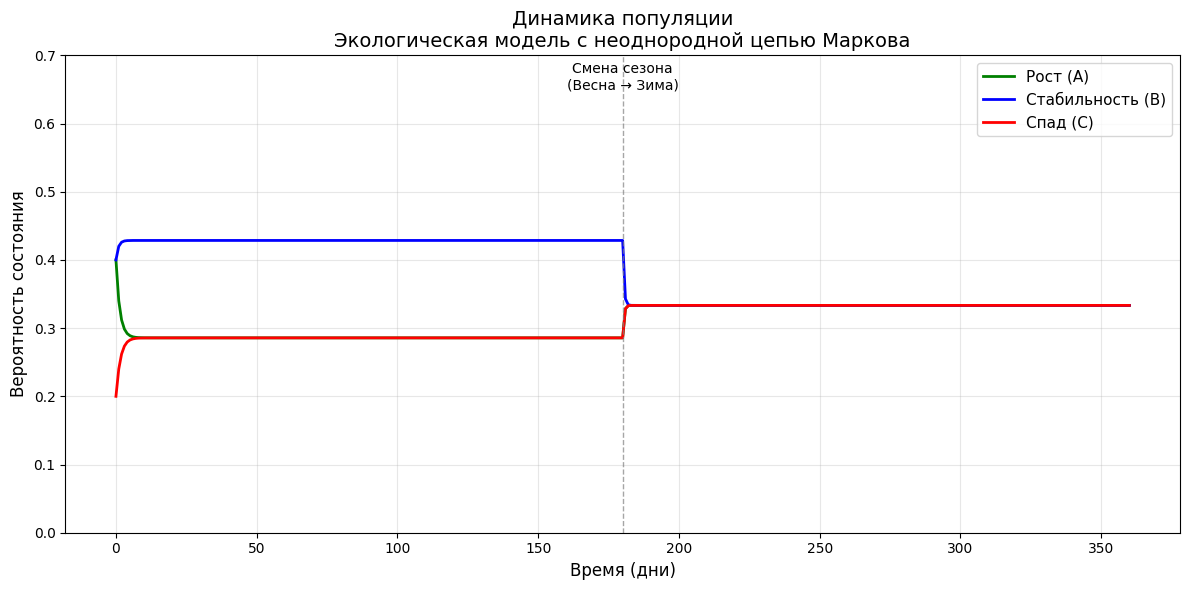

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Экологическая модель популяции (неоднородная цепь Маркова)
# ============================================================

# Матрицы переходов для разных сезонов
# Состояния: 0 - Рост (A), 1 - Стабильность (B), 2 - Спад (C)

# Весна
P_spring = np.array([
    [0.6, 0.3, 0.1],
    [0.2, 0.6, 0.2],
    [0.1, 0.3, 0.6]
])

# Зима
P_winter = np.array([
    [0.5, 0.3, 0.2],
    [0.3, 0.4, 0.3],
    [0.2, 0.3, 0.5]
])

# Список матриц переходов и их длительности
transition_matrices = [P_spring, P_winter]
period_lengths = [180, 180]  # 180 дней весна + 180 дней зима = 1 год

# Начальное распределение
pi_0 = np.array([0.4, 0.4, 0.2])

# ============================================================
# Моделирование неоднородной цепи Маркова
# ============================================================

total_steps = sum(period_lengths)
current_distribution = pi_0.copy()
state_history = [pi_0.copy()]

current_period_index = 0
steps_in_current_period = 0

for step in range(total_steps):
    # Определяем текущий период
    if steps_in_current_period >= period_lengths[current_period_index]:
        current_period_index += 1
        steps_in_current_period = 0

    # Выбираем матрицу переходов для текущего периода
    current_matrix = transition_matrices[current_period_index]

    # Вычисляем распределение на следующем шаге
    current_distribution = current_distribution @ current_matrix

    # Очищаем очень малые значения
    current_distribution[current_distribution < 1e-9] = 0
    # Нормализуем
    current_distribution = current_distribution / np.sum(current_distribution)

    state_history.append(current_distribution.copy())
    steps_in_current_period += 1

# Преобразуем историю в массив
state_history = np.array(state_history)

# ============================================================
# Анализ результатов
# ============================================================

print("=" * 60)
print("ЭКОЛОГИЧЕСКАЯ МОДЕЛЬ ПОПУЛЯЦИИ")
print("=" * 60)

print(f"\nНачальное состояние π(0) = {pi_0}")
print(f"  Рост (A): {pi_0[0]:.3f}")
print(f"  Стабильность (B): {pi_0[1]:.3f}")
print(f"  Спад (C): {pi_0[2]:.3f}")

print(f"\nРаспределение после весны (шаг 180):")
print(f"  π(180) = {state_history[180]}")
print(f"  Рост (A): {state_history[180, 0]:.3f}")
print(f"  Стабильность (B): {state_history[180, 1]:.3f}")
print(f"  Спад (C): {state_history[180, 2]:.3f}")

print(f"\nРаспределение после зимы (шаг 360):")
print(f"  π(360) = {state_history[360]}")
print(f"  Рост (A): {state_history[360, 0]:.3f}")
print(f"  Стабильность (B): {state_history[360, 1]:.3f}")
print(f"  Спад (C): {state_history[360, 2]:.3f}")

# ============================================================
# Визуализация результатов
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(state_history[:, 0], label='Рост (A)', linewidth=2, color='green')
plt.plot(state_history[:, 1], label='Стабильность (B)', linewidth=2, color='blue')
plt.plot(state_history[:, 2], label='Спад (C)', linewidth=2, color='red')

# Вертикальная линия для обозначения смены сезонов
plt.axvline(x=180, color='gray', linestyle='--', alpha=0.7, linewidth=1)
plt.text(180, 0.65, 'Смена сезона\n(Весна → Зима)', ha='center', fontsize=10)

plt.xlabel('Время (дни)', fontsize=12)
plt.ylabel('Вероятность состояния', fontsize=12)
plt.title('Динамика популяции\nЭкологическая модель с неоднородной цепью Маркова', fontsize=14)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.ylim([0, 0.7])

plt.tight_layout()
plt.show()

